# Compare MergedSimCluster vs MergedCaloTruthMergedSimCluster

Compare the two collections from `taus.parquet`:\n- number of objects per event\n- energy (`recEnergy`)\n- 3D position (impact point x, y, z)\n- angles (impact point eta, phi)\n\nFor each variable: overlaid 1D distributions on top, ratio (MergedSimCluster / MergedCaloTruthMergedSimCluster) below. Plots are saved to `/eos/user/m/mmarcheg/ml4reco/data/taus_MergedCaloTruth/plots`.

In [1]:
import os
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

In [3]:

input_file = "/home/mmarcheg/work/ml4reco/hgcal_reco_studies/data/taus.parquet"
output_dir = "/home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots"
os.makedirs(output_dir, exist_ok=True)

events = ak.from_parquet(input_file)
print(events.type)

1000 * {"RecHitHGC": {"RecHitHGC_detId": var * int32, "RecHitHGC_energy": var * float32, "RecHitHGC_time": var * float32, "RecHitHGC_LayerCluster_MatchIdx": var * int32, "RecHitHGC_x": var * float32, "RecHitHGC_y": var * float32, "RecHitHGC_z": var * float32, "RecHitHGC_LayerClusterNumMatch": var * int32, "RecHitHGC_MergedCaloTruthMergedSimClusterBestMatchIdx": var * int32, "RecHitHGC_MergedCaloTruthMergedSimClusterBestMatchQual": var * int32, "RecHitHGC_MergedSimClusterBestMatchIdx": var * int32, "RecHitHGC_MergedSimClusterBestMatchQual": var * int32, "RecHitHGC_SimClusterBestMatchIdx": var * int32, "RecHitHGC_SimClusterBestMatchQual": var * int32}, "MergedSimCluster": {"MergedSimCluster_bunchCrossing": var * int32, "MergedSimCluster_eventId": var * int32, "MergedSimCluster_pdgId": var * int32, "MergedSimCluster_trackIdAtBoundary": var * int32, "MergedSimCluster_boundaryEnergy": var * float32, "MergedSimCluster_impactPoint_eta": var * float32, "MergedSimCluster_impactPoint_phi": var *

In [4]:
collections = {
    "MergedSimCluster": events["MergedSimCluster"],
    "MergedCaloTruthMergedSimCluster": events["MergedCaloTruthMergedSimCluster"],
}

# short field name (without the collection prefix) -> (display name, x-axis label)
variables = {
    "n_objects": ("number of objects", "N objects / event"),
    "recEnergy": ("energy", "energy [GeV]"),
    "impactPoint_x": ("x", "impact point x [cm]"),
    "impactPoint_y": ("y", "impact point y [cm]"),
    "impactPoint_z": ("z", "impact point z [cm]"),
    "impactPoint_eta": ("eta", "impact point $\\eta$"),
    "impactPoint_phi": ("phi", "impact point $\\phi$ [rad]"),
}


def get_flat_values(collection, name, coll_name):
    if name == "n_objects":
        return ak.to_numpy(ak.num(collection[f"{coll_name}_pdgId"], axis=1))
    return ak.to_numpy(ak.flatten(collection[f"{coll_name}_{name}"], axis=None))

In [5]:
def plot_comparison(values1, values2, label1, label2, xlabel, title, bins=50, xrange=None, save_path=None):
    if xrange is None:
        combined = np.concatenate([values1, values2])
        xrange = (combined.min(), combined.max())
    edges = np.linspace(xrange[0], xrange[1], bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    counts1, _ = np.histogram(values1, bins=edges)
    counts2, _ = np.histogram(values2, bins=edges)

    ratio = np.divide(
        counts1, counts2,
        out=np.full_like(counts1, np.nan, dtype=float),
        where=counts2 > 0,
    )

    fig, (ax_main, ax_ratio) = plt.subplots(
        nrows=2, ncols=1, sharex=True, figsize=(8, 8),
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
    )

    hep.histplot(counts1, edges, ax=ax_main, label=label1, histtype="step", linewidth=2)
    hep.histplot(counts2, edges, ax=ax_main, label=label2, histtype="step", linewidth=2)
    ax_main.set_ylabel("Counts")
    ax_main.set_title(title)
    ax_main.legend(fontsize=14)

    ax_ratio.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax_ratio.plot(centers, ratio, "o", color="black", markersize=3)
    ax_ratio.set_xlabel(xlabel)
    ax_ratio.set_ylabel(f"Ratio {label1} / {label2}", fontsize=8)
    ax_ratio.set_ylim(0, 2)

    fig.align_ylabels([ax_main, ax_ratio])

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig, (ax_main, ax_ratio)

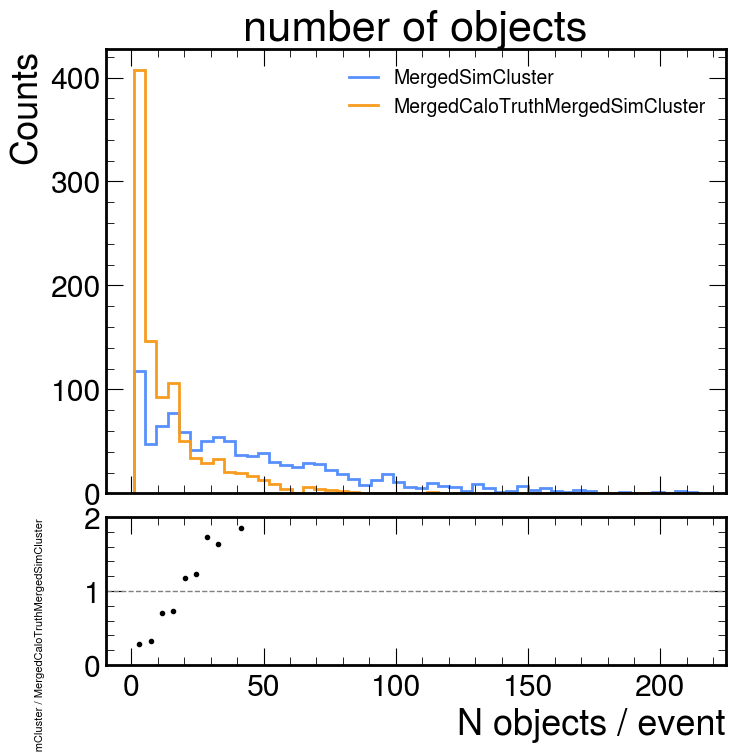

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_n_objects_linear.png


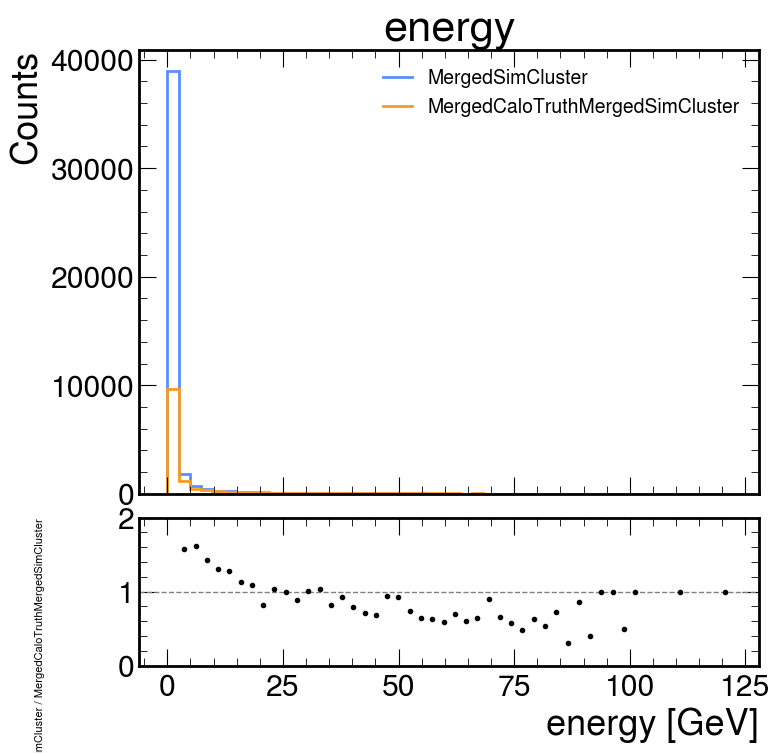

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_recEnergy_linear.png


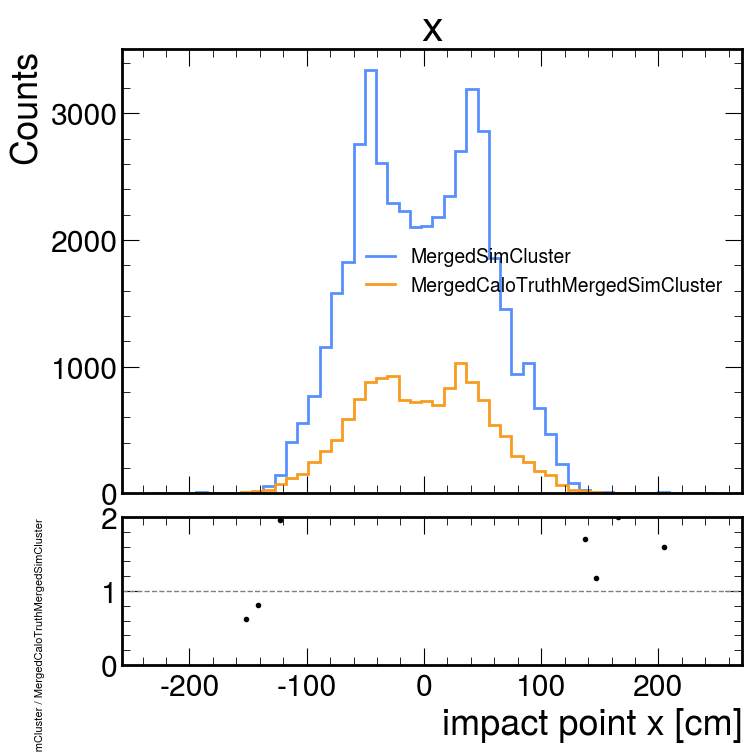

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_impactPoint_x_linear.png


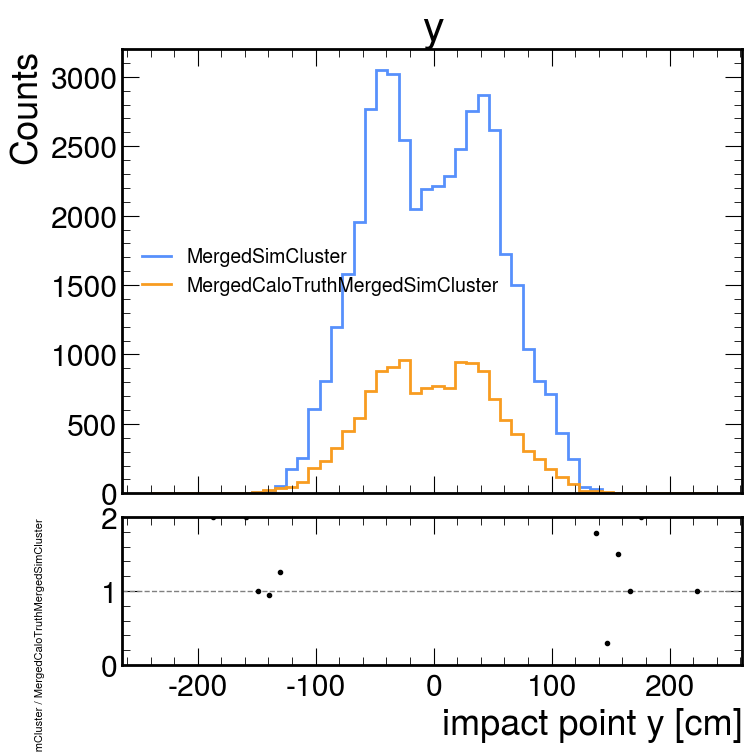

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_impactPoint_y_linear.png


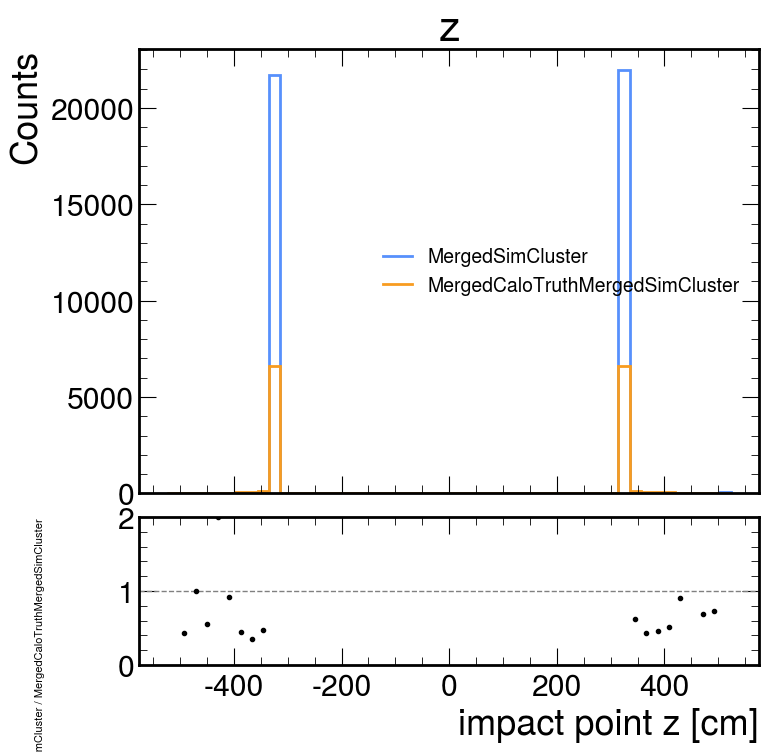

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_impactPoint_z_linear.png


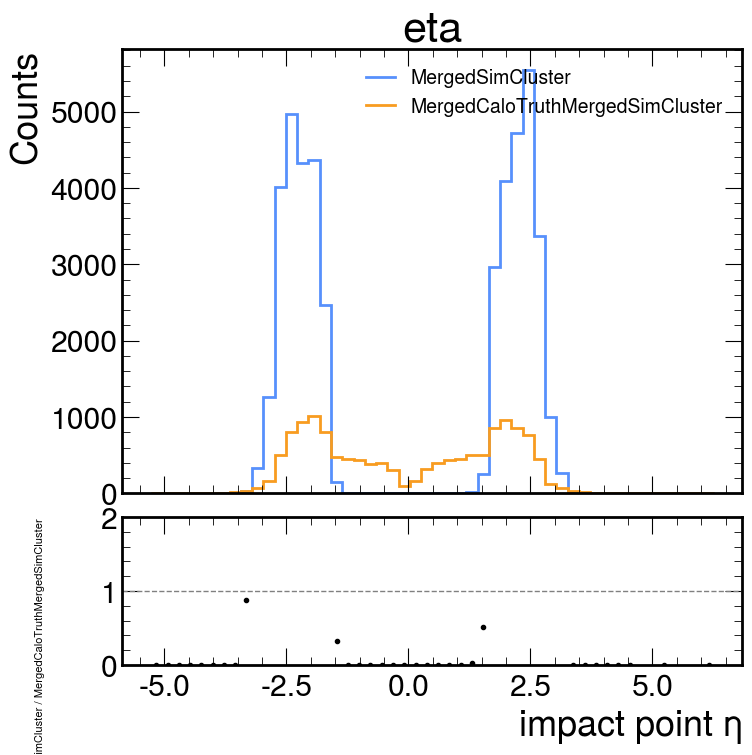

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_impactPoint_eta_linear.png


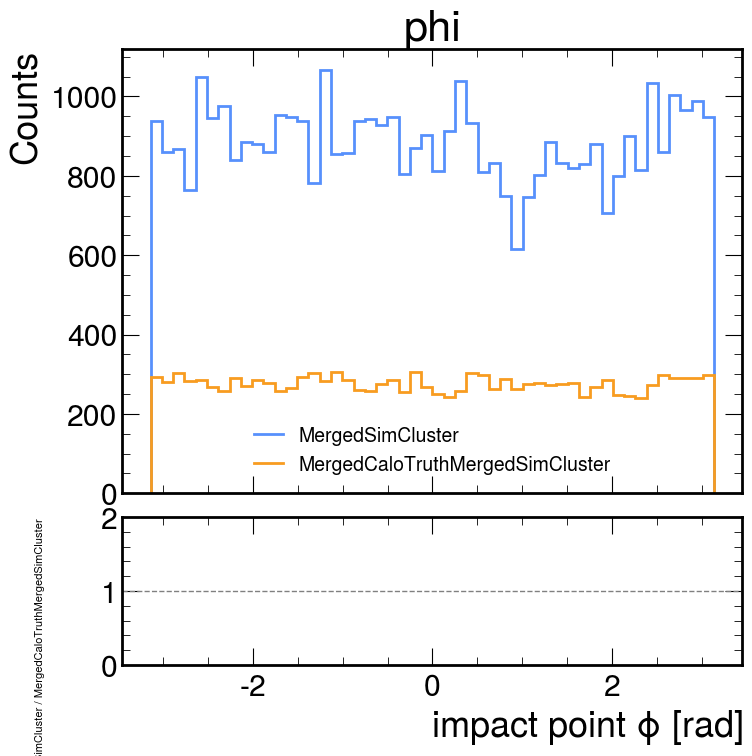

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_impactPoint_phi_linear.png


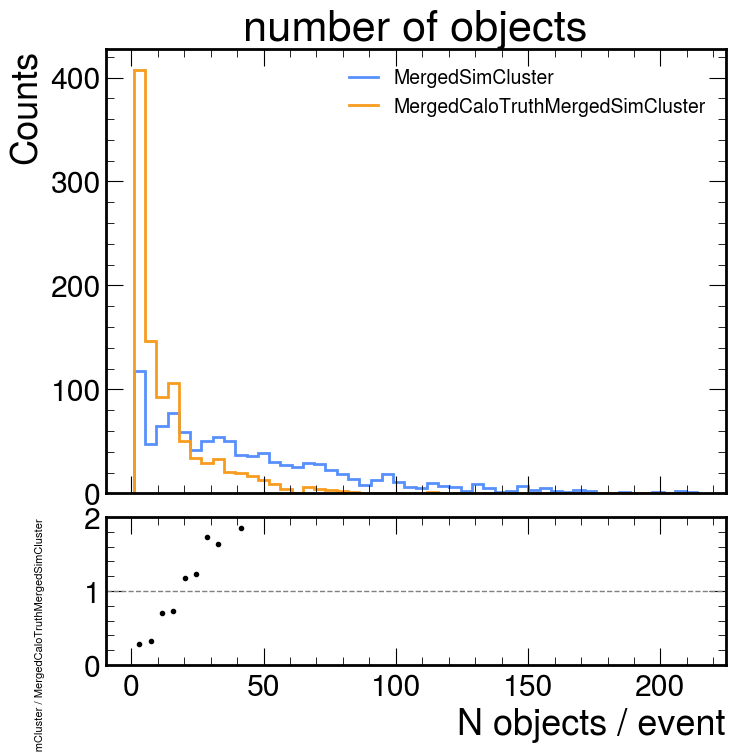

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_n_objects_log.png


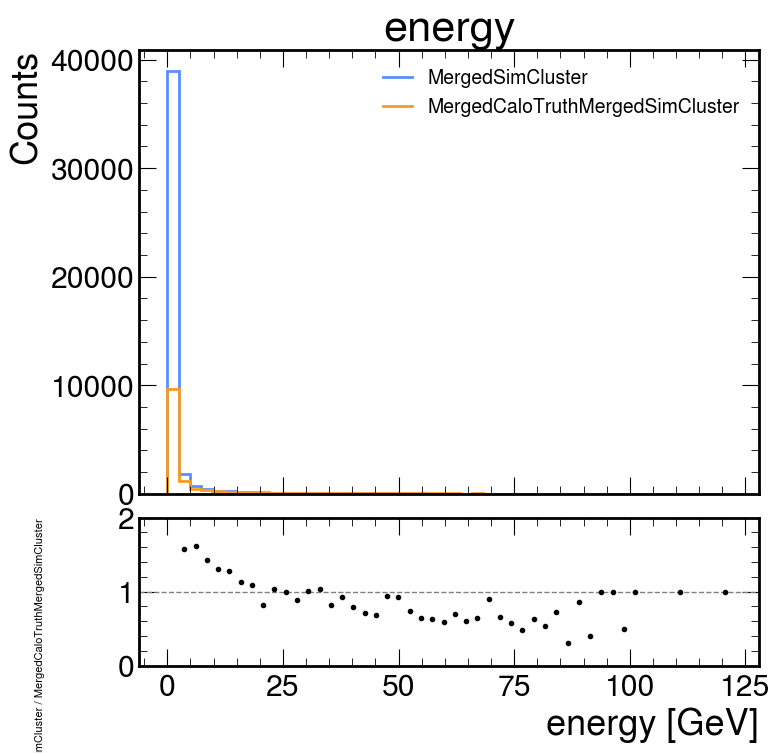

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_recEnergy_log.png


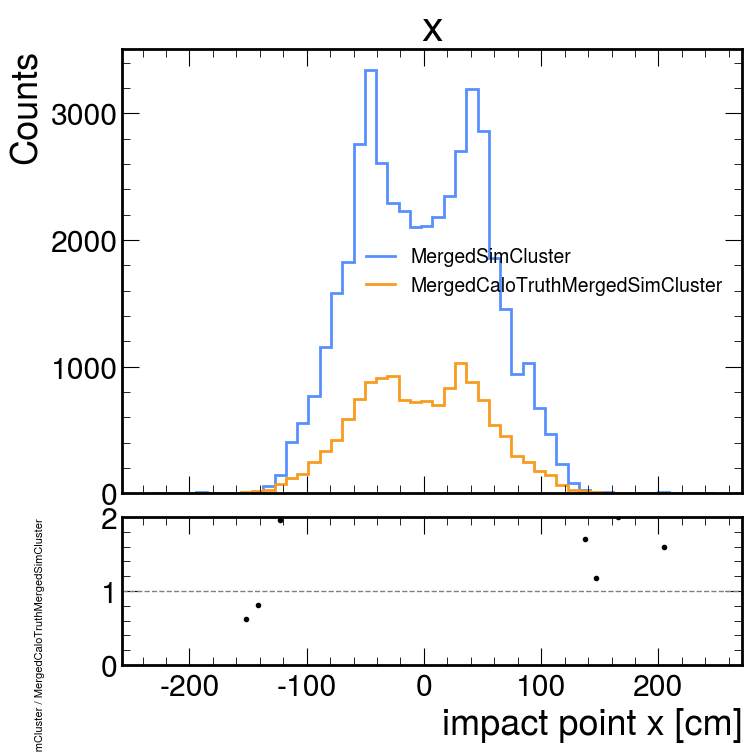

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_impactPoint_x_log.png


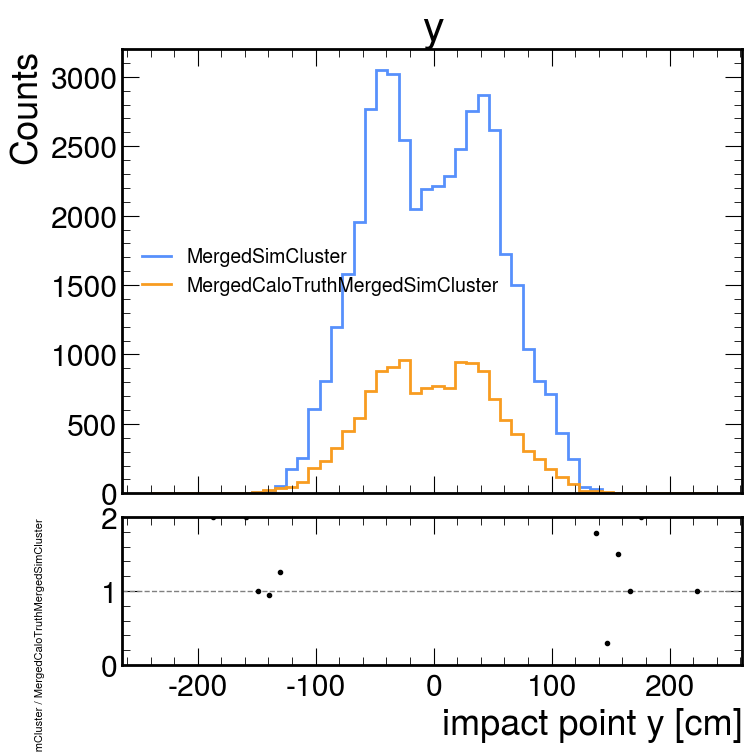

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_impactPoint_y_log.png


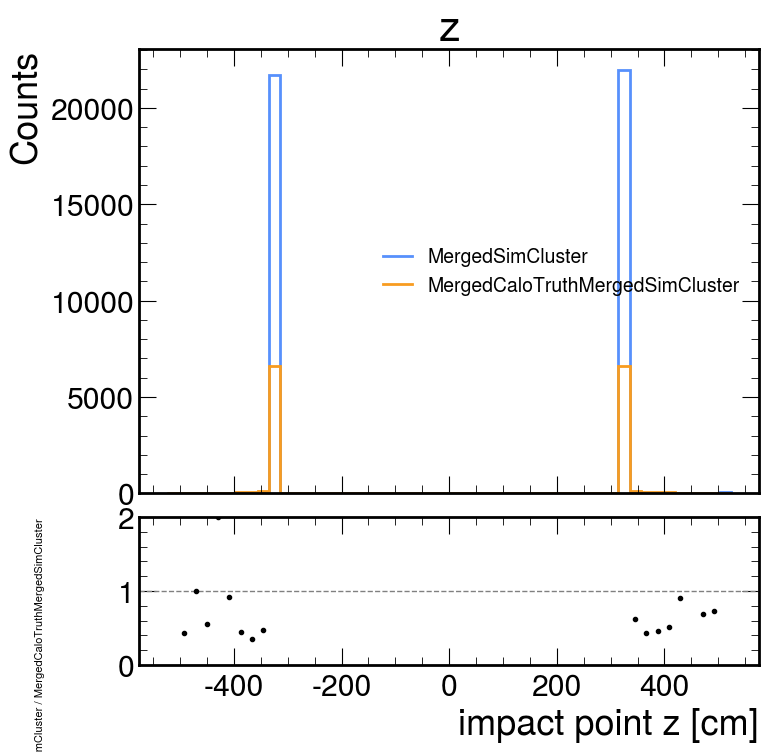

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_impactPoint_z_log.png


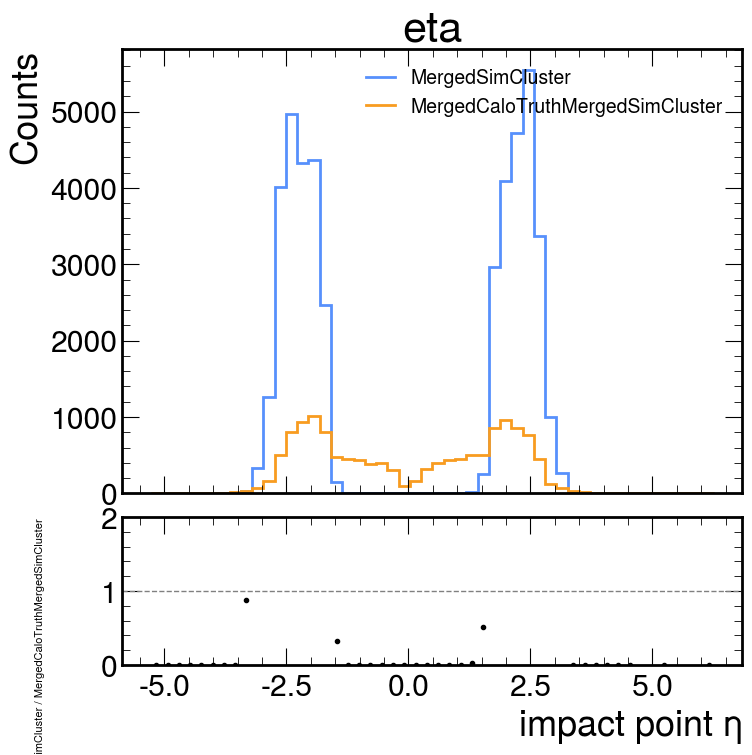

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_impactPoint_eta_log.png


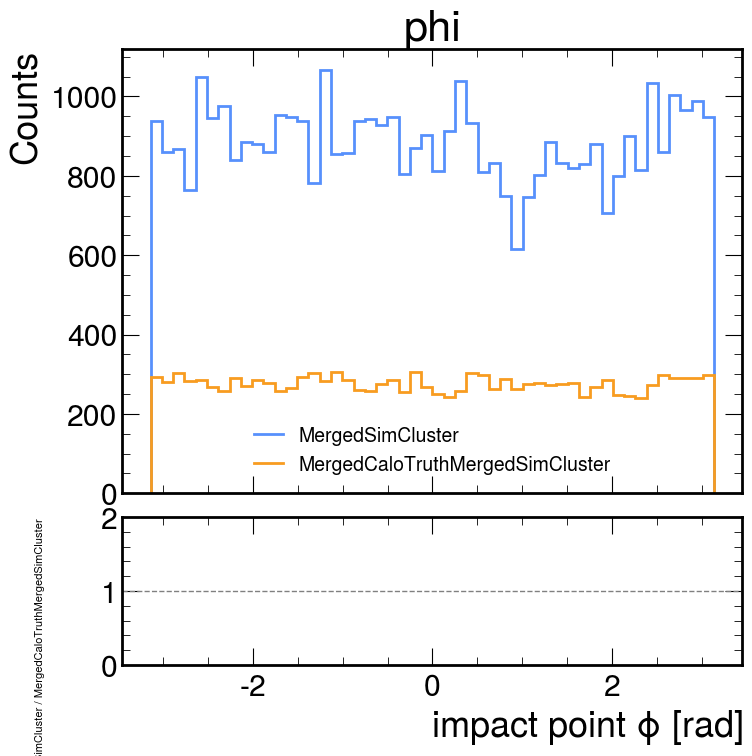

Saved: /home/mmarcheg/work/ml4reco/hgcal_reco_studies/plots/compare_impactPoint_phi_log.png


In [6]:
label1, label2 = "MergedSimCluster", "MergedCaloTruthMergedSimCluster"

for yscale in ["linear", "log"]:
    for field, (title, xlabel) in variables.items():
        values1 = get_flat_values(collections[label1], field, label1)
        values2 = get_flat_values(collections[label2], field, label2)

        save_path = os.path.join(output_dir, f"compare_{field}_{yscale}.png")
        fig, _ = plot_comparison(
            values1, values2,
            label1=label1, label2=label2,
            xlabel=xlabel, title=title,
            save_path=save_path,
        )
        plt.show()
        print(f"Saved: {save_path}")

## Energy-weighted distributions

Same comparisons as above, but every entry is weighted by the `recEnergy` of the
cluster it belongs to, so each histogram shows the total reconstructed energy per bin
instead of the number of entries.

For `n_objects` (one entry per event) the weight is the sum of `recEnergy` over all
clusters of that event.

Plots are saved to the same output directory with the `_energy_weighted` suffix.

In [ ]:
def get_flat_weights(collection, name, coll_name):
    """recEnergy weights, aligned one-to-one with the entries from get_flat_values."""
    energy = collection[f"{coll_name}_recEnergy"]
    if name == "n_objects":
        # one entry per event -> weight by the total recEnergy of the event
        return ak.to_numpy(ak.sum(energy, axis=1))
    return ak.to_numpy(ak.flatten(energy, axis=None))

In [ ]:
def plot_comparison_weighted(
    values1, values2, weights1, weights2, label1, label2, xlabel, title,
    bins=50, xrange=None, yscale="linear", save_path=None,
):
    if xrange is None:
        combined = np.concatenate([values1, values2])
        xrange = (combined.min(), combined.max())
    edges = np.linspace(xrange[0], xrange[1], bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    counts1, _ = np.histogram(values1, bins=edges, weights=weights1)
    counts2, _ = np.histogram(values2, bins=edges, weights=weights2)

    ratio = np.divide(
        counts1, counts2,
        out=np.full_like(counts1, np.nan, dtype=float),
        where=counts2 > 0,
    )

    fig, (ax_main, ax_ratio) = plt.subplots(
        nrows=2, ncols=1, sharex=True, figsize=(8, 8),
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
    )

    hep.histplot(counts1, edges, ax=ax_main, label=label1, histtype="step", linewidth=2)
    hep.histplot(counts2, edges, ax=ax_main, label=label2, histtype="step", linewidth=2)
    ax_main.set_ylabel("$\\sum E_{rec}$ [GeV]")
    ax_main.set_yscale(yscale)
    ax_main.set_title(title)
    ax_main.legend(fontsize=14)

    ax_ratio.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax_ratio.plot(centers, ratio, "o", color="black", markersize=3)
    ax_ratio.set_xlabel(xlabel)
    ax_ratio.set_ylabel(f"Ratio {label1} / {label2}", fontsize=8)
    ax_ratio.set_ylim(0, 2)

    fig.align_ylabels([ax_main, ax_ratio])

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig, (ax_main, ax_ratio)

In [ ]:
label1, label2 = "MergedSimCluster", "MergedCaloTruthMergedSimCluster"

for yscale in ["linear", "log"]:
    for field, (title, xlabel) in variables.items():
        values1 = get_flat_values(collections[label1], field, label1)
        values2 = get_flat_values(collections[label2], field, label2)
        weights1 = get_flat_weights(collections[label1], field, label1)
        weights2 = get_flat_weights(collections[label2], field, label2)

        save_path = os.path.join(output_dir, f"compare_{field}_{yscale}_energy_weighted.png")
        fig, _ = plot_comparison_weighted(
            values1, values2, weights1, weights2,
            label1=label1, label2=label2,
            xlabel=xlabel, title=f"{title} (energy weighted)",
            yscale=yscale,
            save_path=save_path,
        )
        plt.show()
        print(f"Saved: {save_path}")

## Energy fraction in the central region $|\eta| < 1.5$

Fraction of the total `recEnergy` carried by clusters whose impact point falls in
$-1.5 < \eta < 1.5$, for each of the two collections.

In [ ]:
eta_min, eta_max = -1.5, 1.5

summary = {}
for label, collection in collections.items():
    eta = ak.to_numpy(ak.flatten(collection[f"{label}_impactPoint_eta"], axis=None))
    energy = ak.to_numpy(ak.flatten(collection[f"{label}_recEnergy"], axis=None))

    central = (eta > eta_min) & (eta < eta_max)

    e_total = energy.sum()
    e_central = energy[central].sum()
    summary[label] = {
        "n_total": eta.size,
        "n_central": int(central.sum()),
        "e_total": e_total,
        "e_central": e_central,
        "e_frac": e_central / e_total if e_total > 0 else np.nan,
        "n_frac": central.sum() / eta.size if eta.size > 0 else np.nan,
    }

print(f"Clusters with {eta_min} < eta < {eta_max}\n")
header = f"{'collection':<34} {'N central':>12} {'N total':>12} {'N frac':>9} {'E central [GeV]':>17} {'E total [GeV]':>15} {'E frac':>9}"
print(header)
print("-" * len(header))
for label, s in summary.items():
    print(
        f"{label:<34} {s['n_central']:>12d} {s['n_total']:>12d} {s['n_frac']:>8.3%} "
        f"{s['e_central']:>17.1f} {s['e_total']:>15.1f} {s['e_frac']:>8.3%}"
    )